# Backbone ColoredMNIST

## Colored MNIST dataset

Found existing ColoredMNIST dataset in datasets, skipping download.


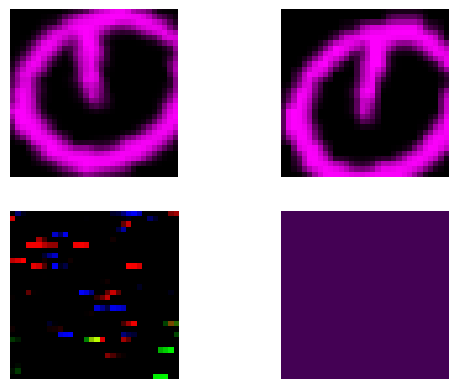

In [4]:
from oxels.datasets import DGPerspectiveDataset
import matplotlib.pyplot as plt

from oxels.losses import contrastive_loss
from oxels.models.metrics_mixin import MetricsMixin

dataset = DGPerspectiveDataset(
    path="datasets",
    dataset="ColoredMNIST",
    h=32,
    w=32,
    split="test",
    domain_split="id",
    seed=0,
)

view1, view2, indices, flags, mask1, mask2 = dataset[6]
plt.subplot(221)
plt.imshow(view1.transpose(1, 2, 0))
plt.axis("off")
plt.subplot(222)
plt.imshow(view2.transpose(1, 2, 0))
plt.axis("off")
plt.subplot(223)
plt.imshow((view2.reshape((-1,3))[indices]*flags[:,None]).reshape(view2.shape).transpose(1, 2, 0))
plt.axis("off")
plt.subplot(224)
plt.imshow(mask1.reshape(view1.transpose(1,2,0).shape[:2]))
plt.axis("off")
plt.show()

## ColoredMNIST Model/Dataset

In [9]:
from collections.abc import Sequence
import os
from torch.utils.data import DataLoader
from torchvision import transforms

from oxels.networks import SimpleUNet
from oxels.models.base_model import BaseModel
from oxels.datasets import DGPerspectiveDataset


class ColoredMNISTModel(BaseModel):
    def __init__(
        self,
        *,
        stage_channels: Sequence[int] = (32, 64, 128, 256),
        num_res_blocks: Sequence[int] = (2, 2, 2, 4),
        num_oxels: int = 64,
        num_norm_groups: int = 8,
        learning_rate: float = 1e-3,
        weight_decay: float = 0.004,
        dropout_stages: Sequence[int],
        dropout: float = 0.1,
        attention_stages: Sequence[int],
        lr_div_factor: float = 25.0,
        lr_final_div_factor: float = 1e4,
        lr_pct_start: float = 0.05,
        train_batch_size: int,
        val_batch_size: int,
        image_size: int = 256,
        contrastive_loss_weight: float = 0.5,
        frac_keep: float = 0.125,
    ):
        num_stages = len(stage_channels)
        has_attention = [False] * num_stages
        for stage in attention_stages:
            has_attention[stage] = True

        residual_dropout = [0.0] * num_stages
        for stage in dropout_stages:
            residual_dropout[stage] = dropout

        backbone = SimpleUNet(
            height=image_size,
            width=image_size,
            in_channels=3,
            out_channels=num_oxels,
            channels_of_stage=stage_channels,
            has_attention=has_attention,
            num_res_blocks=num_res_blocks,
            norm_groups=num_norm_groups,
            residual_dropout=residual_dropout,
        )
        super().__init__(
            backbone=backbone,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            lr_div_factor=lr_div_factor,
            lr_final_div_factor=lr_final_div_factor,
            lr_pct_start=lr_pct_start,
            contrastive_loss_weight=contrastive_loss_weight,
        )
        self.frac_keep = frac_keep
        self.save_hyperparameters()

    def train_dataloader(self):
        dataset = DGPerspectiveDataset(
            path="datasets",
            dataset="ColoredMNIST",
            h=self.hparams.image_size,
            w=self.hparams.image_size,
            split="train",
            domain_split="id",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((32, 32))
            ]),
            frac_keep=self.frac_keep,
        )
        return DataLoader(
            dataset,
            batch_size=self.hparams.train_batch_size,
            shuffle=True,
            pin_memory=True,
            num_workers=0,#len(os.sched_getaffinity(0)),
            drop_last=True,
        )

    def val_dataloader(self):
        dataset = DGPerspectiveDataset(
            path="datasets",
            dataset="ColoredMNIST",
            h=self.hparams.image_size,
            w=self.hparams.image_size,
            split="val",
            domain_split="id",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((32, 32))
            ]),
            frac_keep=self.frac_keep,
        )
        return DataLoader(
            dataset,
            batch_size=self.hparams.val_batch_size,
            shuffle=False,
            pin_memory=True,
            num_workers=0,#len(os.sched_getaffinity(0)),
            drop_last=False,
        )

    def val_dataloader_ood(self):
        dataset = DGPerspectiveDataset(
            path="datasets",
            dataset="ColoredMNIST",
            h=self.hparams.image_size,
            w=self.hparams.image_size,
            split="val",
            domain_split="ood",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((32, 32))
            ]),
            frac_keep=self.frac_keep,
        )
        return DataLoader(
            dataset,
            batch_size=self.hparams.val_batch_size,
            shuffle=False,
            pin_memory=True,
            num_workers=0,#len(os.sched_getaffinity(0)),
            drop_last=False,
        )


## Training Args, Dataset and Model

In [22]:
import lightning as L
import torch
from lightning.pytorch import callbacks
from lightning.pytorch.loggers import WandbLogger

import wandb
from oxels.callbacks import ShowOxels


torch.cuda.empty_cache()
torch.set_float32_matmul_precision("medium")

print("Device Count:", torch.cuda.device_count())
project = "ColoredMNIST-ColorClassifier"
total_steps = 100_000
image_size = 32
num_nodes = 1
num_devices = 1
train_batch_size = 128
val_batch_size = 256
learning_rate = 1e-3
lr_pct_start = 0.05
weight_decay = 1e-6

contrastive_loss_weight = 0.5
frac_keep = 0.25

num_stages = 3
num_oxels = 32
base_channels = 32
stage_channels = [32, 64, 64, 128]
num_res_blocks = [1, 2, 2, 4]
stage_channels = stage_channels[:num_stages]
num_res_blocks = num_res_blocks[:num_stages]

dropout_stages = [-2, -1]
dropout = 0.1

attention_stages = [stage for stage in range(4, num_stages)]

model_config = dict(
    stage_channels=stage_channels,
    num_res_blocks=num_res_blocks,
    num_oxels=num_oxels,
    dropout_stages=dropout_stages,
    dropout=dropout,
    attention_stages=attention_stages,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    lr_pct_start=lr_pct_start,
    lr_div_factor=25.0,
    lr_final_div_factor=1e4,
    train_batch_size=train_batch_size,
    val_batch_size=val_batch_size,
    image_size=image_size,
    contrastive_loss_weight=contrastive_loss_weight,
    frac_keep=frac_keep,
)

trainer_config = dict(
    gradient_clip_val=3.0,
    gradient_clip_algorithm="value",
    max_steps=total_steps,
    accelerator="gpu",
    strategy="auto",
    devices=num_devices,
    precision="16-mixed",
    num_nodes=num_nodes,
)

model = ColoredMNISTModel(**model_config)

with torch.device("cpu"):
    train_images = [model.train_dataloader().dataset.dataset[i][0] for i in range(4)]
    train_images = torch.stack(train_images)
    validation_images = [model.val_dataloader().dataset.dataset[i][0] for i in range(4)]
    validation_images = torch.stack(validation_images)
    validation_images_ood = [model.val_dataloader_ood().dataset.dataset[i][0] for i in range(4)]
    validation_images_ood = torch.stack(validation_images_ood)

num_parameters = sum(p.numel() for p in model.parameters())

config = model_config | trainer_config

Device Count: 1
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.


## Initialize WandB run

In [23]:
run = wandb.init(
    entity="kl_divergence-rensselaer-polytechnic-institute",
    project=project,
    config=config,
    dir="wandb_results",
)

logger = WandbLogger(
    experiment=run,
)

wandb.summary["num_parameters"] = num_parameters
wandb.summary["model_type"] = "BackboneColoredMNIST"
run_name = wandb.run.name
run_id = wandb.run.id
print(f"name: {run_name} \t run id:{run_id}")

name: vibrant-voice-9 	 run id:0cs9edot


## Training

In [24]:
ckpt_dir = os.path.join("lightning_logs", str(run_name))
os.makedirs(ckpt_dir, exist_ok=True)
with open(os.path.join(ckpt_dir, "wandb_run_id.txt"), "w") as f:
    f.write(run_id)
f.close()
trainer = L.Trainer(
    **trainer_config,
    callbacks=[
        callbacks.LearningRateMonitor(logging_interval="step"),
        callbacks.ModelCheckpoint(
            dirpath=ckpt_dir,
            monitor="validation/loss",
            mode="min",
            save_top_k=1,
            filename="best_model",
            save_last=True,
        ),
        ShowOxels(images=train_images, every_n_epochs=10, caption="Train Oxels"),
        ShowOxels(images=validation_images, every_n_epochs=10, caption="Validation Oxels"),
        ShowOxels(images=validation_images_ood, every_n_epochs=10, caption="Validation OOD Oxels"),
    ],
    logger=logger,
)

try:
    trainer.fit(model)

    result = trainer.callback_metrics["validation/loss"]
    wandb.summary["result"] = result

finally:
    # clean up
    wandb.finish()

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/nbracher/anaconda3/envs/oxels/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /home/nbracher/Documents/Projects/oxels/notebooks/lightning_logs/vibrant-voice-9 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type       | Params | Mode 
------------------------------------------------
0 | backbone | SimpleUNet | 993 K  | train
------------------------------------------------
993 K     Trainable params
64        Non-trainable params
993 K     Total params
3.975     Total estimated model params size (MB)
217       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/nbracher/anaconda3/envs/oxels/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.


/home/nbracher/anaconda3/envs/oxels/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100000` reached.


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇█████
lr-AdamW,▇███████▇▇▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇██
training/loss_epoch,█▆▅▄▄▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
training/loss_step,█▄▃▃▃▂▂▂▂▂▂▂▂▁▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation/loss,█▅▄▄▄▃▃▂▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,343
lr-AdamW,0.0
model_type,BackboneColoredMNIST...
num_parameters,993664
result,0.00689


# Resume Training Testing

## Load from Checkpoint

## Resume Training

In [ ]:
run_name = "brisk-serenity-59"

ckpt_dir = os.path.join("lightning_logs", str(run_name))
with open(os.path.join(ckpt_dir, "wandb_run_id.txt"), "r") as f:
    run_id = f.read().strip()
model = ColoredMNISTModel.load_from_checkpoint(os.path.join(ckpt_dir, "best_model.ckpt"))
print(f"Loaded model from {os.path.join(ckpt_dir, 'best_model.ckpt')} with run id {run_id} and name {run_name}")

run = wandb.init(
    entity="kl_divergence-rensselaer-polytechnic-institute",
    project=project,
    config=config,
    dir="wandb_results",
    id=run_id, resume="must")
logger = WandbLogger(
    experiment=run,
)

wandb.summary["num_parameters"] = num_parameters

trainer = L.Trainer(
    **trainer_config,
    callbacks=[
        callbacks.LearningRateMonitor(logging_interval="step"),
        callbacks.ModelCheckpoint(
            dirpath=ckpt_dir,
            monitor="validation/loss",
            mode="min",
            save_top_k=1,
            filename="best_model",
            save_last=True,
        ),
        ShowOxels(images=train_images, every_n_epochs=10, caption="Train Oxels"),
        ShowOxels(images=validation_images, every_n_epochs=10, caption="Validation Oxels"),
        ShowOxels(images=validation_images_ood, every_n_epochs=10, caption="Validation OOD Oxels"),
    ],
    logger=logger,
)

try:
    trainer.fit(model, ckpt_path=os.path.join(ckpt_dir, "last.ckpt"))
    result = trainer.callback_metrics["validation/loss"]
    wandb.summary["result"] = result

finally:
    # clean up
    wandb.finish()

# Downstream Task: ColoredMNIST Classification

## Create Downstream Dataset

Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.


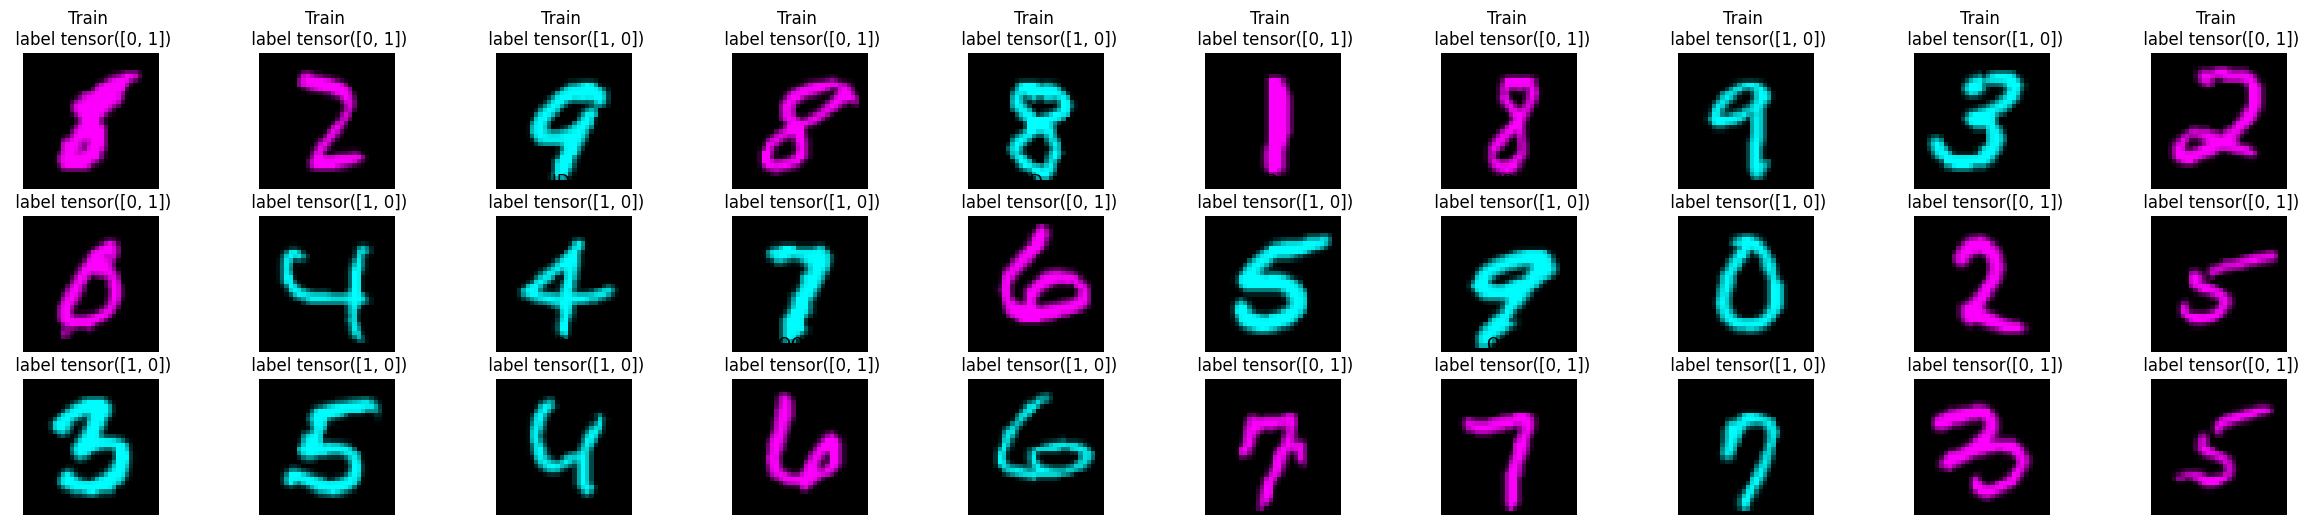

In [30]:
import torch
from torch.utils.data import Dataset, random_split
from typing import Literal
from pathlib import Path
import matplotlib.pyplot as plt
from torchvision import transforms

from oxels.datasets.dg import MultiDomainDataset


class DGDataset(Dataset):
    splits = {
        "train": 0.8,
        "val": 0.1,
        "test": 0.1,
    }

    def __init__(
        self,
        *,
        path: str,
        dataset: str = "camelyon17",
        split: Literal["train", "val", "test"] = "train",
        domain_split: Literal["id", "ood"] = "id",
        seed: int = 0,
        augmentations: callable = None,
        domain_transforms: callable = None,
    ):
        self.path = Path(path)
        self.split = split
        self.domain_split = domain_split
        self.augmentations = augmentations
        self.domain_transforms = domain_transforms
        self.dataset = self._get_dataset(dataset, seed=seed)

    def __getitem__(self, item):
        with torch.device("cpu"):
            rgb, label, _ = self.dataset.__getitem__(item)
        rgb = rgb.numpy(force=True)
        return rgb, label

    def __len__(self):
        return len(self.dataset)

    def _get_raw_dataset(self, dataset: str):
        match dataset.lower():
            case "camelyon17":
                from oxels.datasets.dg import Camelyon17

                return Camelyon17(self.path, download=True)
            case "coloredmnist":
                from oxels.datasets.dg import ColoredMNIST

                return ColoredMNIST(self.path, download=True, transform=self.augmentations, domain_transforms=self.domain_transforms)
            case "fmowregion":
                from oxels.datasets.dg import FMoWRegion

                return FMoWRegion(self.path, download=True)
            case "fmowyear":
                from oxels.datasets.dg import FMoWYear

                return FMoWYear(self.path, download=True)
            case "officehome":
                from oxels.datasets.dg import OfficeHome

                return OfficeHome(self.path, download=True)
            case "pacs":
                from oxels.datasets.dg import PACS

                return PACS(self.path, download=True)
            case "rotatedmnist":
                from oxels.datasets.dg import RotatedMNIST

                return RotatedMNIST(self.path, download=True)
            case "terraincognita":
                from oxels.datasets.dg import TerraIncognita

                return TerraIncognita(self.path, download=True)
            case "vlcs":
                from oxels.datasets.dg import VLCS

                return VLCS(self.path, download=True)
            case "povertymapurbanicity":
                from oxels.datasets.dg import PovertyMapUrbanicity

                return PovertyMapUrbanicity(self.path, download=True)
            case "povertymapcountry":
                from oxels.datasets.dg import PovertyMapCountry

                return PovertyMapCountry(self.path, download=True)
            case other:
                raise NotImplementedError(f"Unrecognized dataset: {other}")

    def _get_splits(self, dataset, seed):
        if self.domain_split == "id":
            domains = dataset.all_domains[:-1]
        elif self.domain_split == "ood":
            domains = dataset.all_domains[-1:]
        else:
            raise ValueError(f"Expected domain_split to be 'id' or 'ood', got {self.domain_split}.")

        # get the full domains
        domains = [dataset.domain(d) for d in domains]

        if self.domain_split != "ood":
            # get the seeded random splits for the given domain
            split = list(self.splits.keys()).index(self.split)
            generator = torch.Generator().manual_seed(seed)
            domains = [random_split(d, list(self.splits.values()), generator=generator)[split] for d in domains]

        return domains

    def _get_dataset(self, dataset, seed=0):
        raw_dataset = self._get_raw_dataset(dataset)
        splits = self._get_splits(raw_dataset, seed)

        return MultiDomainDataset(
            *splits, in_distribution=self.domain_split == "id", n_domains=len(raw_dataset.all_domains)
        )
from oxels.datasets.dg.mnist import transforms as dtransforms
dataset_train = DGDataset(
    path="datasets",
    dataset="ColoredMNIST",
    split="train",
    domain_split="id",
    seed=0,
    augmentations=transforms.Compose([
        transforms.Resize((32, 32))
    ]),
    domain_transforms= [
                dtransforms.Compose(
                    [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
                ),
                dtransforms.Compose(
                    [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
                ),
                dtransforms.Compose(
                    [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
                ),
            ]
)


dataset_id = DGDataset(
    path="datasets",
    dataset="ColoredMNIST",
    split="val",
    domain_split="id",
    seed=0,
    augmentations=transforms.Compose([
        transforms.Resize((32, 32))
    ]),
    domain_transforms= [
                dtransforms.Compose(
                    [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
                ),
                dtransforms.Compose(
                    [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
                ),
                dtransforms.Compose(
                    [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
                ),
            ]
)


dataset_ood = DGDataset(
    path="datasets",
    dataset="ColoredMNIST",
    split="val",
    domain_split="ood",
    seed=0,
    augmentations=transforms.Compose([
        transforms.Resize((32, 32))
    ]),
    domain_transforms= [
                dtransforms.Compose(
                    [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
                ),
                dtransforms.Compose(
                    [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
                ),
                dtransforms.Compose(
                    [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
                ),
            ]
)


n_samples = 10
fig, axs = plt.subplots(3, n_samples, figsize=(n_samples*3, 2*3))
for i in range(n_samples):
    img, label = dataset_train[i]
    axs[0, i].imshow(img.transpose(1, 2, 0))
    axs[0, i].axis("off")
    axs[0, i].set_title(f"Train \n label {label}")

for i in range(n_samples):
    img, label = dataset_id[i]
    axs[1, i].imshow(img.transpose(1, 2, 0))
    axs[1, i].axis("off")
    axs[1, i].set_title(f"ID \n label {label}")

for i in range(n_samples):
    img, label = dataset_ood[i]
    axs[2, i].imshow(img.transpose(1, 2, 0))
    axs[2, i].axis("off")
    axs[2, i].set_title(f"OOD \n label {label}")
plt.show()

## Load Backbone

In [44]:
import os


backbone_run_name = "amber-terrain-77"
#backbone_run_name = "scarlet-sky-138"
backbone_run_name = "zesty-durian-7"
ckpt_dir = os.path.join("lightning_logs", str(backbone_run_name))
with open(os.path.join(ckpt_dir, "wandb_run_id.txt"), "r") as f:
    backbone_run_id = f.read().strip()
backbone = ColoredMNISTModel.load_from_checkpoint(os.path.join(ckpt_dir, "best_model.ckpt"))
print(f"Loaded model from {os.path.join(ckpt_dir, 'best_model.ckpt')} with run id {backbone_run_id} and name {backbone_run_name}")
num_oxels = backbone.hparams.num_oxels

Loaded model from lightning_logs/zesty-durian-7/best_model.ckpt with run id o287ks6p and name zesty-durian-7


## Pixelwise Classifier

### ArgmaxPixel Classifier

In [ ]:
import torch
import torch.nn as nn

class ArgmaxPixelClassifier(nn.Module):
    def __init__(self, in_channels: int, head_channels_out: int, head_group: int, num_classes: int):
        super().__init__()
        self.num_classes = num_classes
        # pixelwise head: C → num_classes, no spatial context
        #self.pixel_head = nn.Conv2d(in_channels, head_channels_out, groups=head_group, kernel_size=1, bias=True)
        self.pixel_head = nn.Sequential(
            nn.Linear(in_channels, 150),
            nn.GELU(),
            nn.Linear(150, 100),
            nn.GELU(),
            nn.Linear(100, 50),
            nn.GELU(),
            nn.Linear(50, 1),
        )
        # final image‐level classifier on one pixel’s embedding
        #self.global_head = nn.Linear(in_channels, num_classes, bias=True)
        self.global_head = nn.Sequential(
            nn.Linear(in_channels, 150),
            nn.GELU(),
            nn.Linear(150, 100),
            nn.GELU(),
            nn.Linear(100, 50),
            nn.GELU(),
            nn.Linear(50, num_classes),
        )

    def forward(self, x):
        # x: [B, C, H, W]
        B, C, H, W = x.shape

        # 1) pixel‐wise logits: [B, K, H, W]
        px_logits = self.pixel_head(x.permute(0, 2, 3, 1)).permute(0, 3, 1, 2)

        # 2) importance score per pixel: sum over classes → [B, H, W]
        #    (you could also use margin = |logit1 − logit0| for binary)
        importance = px_logits.sum(dim=1)

        # 3) flatten spatial → [B, H*W], pick the index of the max
        imp_flat = importance.view(B, -1)
        idx     = imp_flat.argmax(dim=1)      # [B]

        # 4) recover (i,j) coords
        i = idx // W
        j = idx %  W

        # 5) gather that pixel’s embedding: [B, C]
        batch_idx = torch.arange(B, device=x.device)
        sel_emb   = x[batch_idx, :, i, j]     # [B, C]

        # 6) final linear classifier → [B, K]
        return self.global_head(sel_emb)

num_classes = 2
classifier = ArgmaxPixelClassifier(in_channels=num_oxels, num_classes=num_classes, head_channels_out=32, head_group=1)
print("Downstream model number of parameters: ", sum(p.numel() for p in classifier.parameters()))


### Top‐K Pixel Classifier

In [ ]:
import torch
import torch.nn as nn

class TopKPixelClassifier(nn.Module):
    def __init__(self, in_channels: int, num_classes: int, k: int, head_channels_out: int = 32, head_group: int = 1):
        super().__init__()
        self.k = k
        self.num_classes = num_classes
        # pixel‐wise head: C→num_classes
        self.pixel_head  = nn.Conv2d(in_channels, head_channels_out, groups=head_group, kernel_size=1, bias=True)
        # global head on the pooled embedding
        self.global_head = nn.Linear(in_channels*k, num_classes, bias=True)

    def forward(self, x):
        # x: [B, C, H, W]
        B, C, H, W = x.shape

        # (1) per‐pixel logits [B, K, H, W]
        px_logits = self.pixel_head(x)

        # (2) importance per pixel: pick class-1 logit (for binary)
        #     or use margin = |logit1 - logit0|
        imp = px_logits[:, 1, :, :]               # [B, H, W]

        # (3) flatten and topk over H*W
        imp_flat = imp.view(B, -1)                # [B, H*W]
        vals, idxs = imp_flat.topk(self.k, dim=1) # both [B, k]

        # (4) recover (i,j) coords
        rows = idxs // W                          # [B, k]
        cols = idxs %  W                          # [B, k]

        # (5) gather the k embeddings per batch
        batch_idx = torch.arange(B, device=x.device).unsqueeze(1)  # [B, 1]
        # x[batch, :, row, col] → [B, C, k], then permute → [B, k, C]
        sel_emb = x[batch_idx, :, rows, cols]
        sel_emb = sel_emb.permute(0, 2, 1)     # [B, k, C]

        # (6) aggregate top‐k embeddings (mean or sum)
        #agg_emb = sel_emb.mean(dim=1)             # [B, C]
        agg_emb = sel_emb.flatten(start_dim=1)  # [B, k*C]
        # (7) final linear classifier → [B, num_classes]
        return self.global_head(agg_emb)

num_classes = 2
k = 4
classifier = TopKPixelClassifier(in_channels=num_oxels, num_classes=num_classes, k=k, head_channels_out=32, head_group=32)
print("Downstream model number of parameters: ", sum(p.numel() for p in classifier.parameters()))
print(classifier(torch.randn(1, num_oxels, 32, 32)))


In [ ]:
class TopKPixelClassifier(nn.Module):
    def __init__(self, in_channels: int, num_classes: int, k: int, head_channels_out: int = 32, head_group: int = 1):
        super().__init__()
        self.k = k
        self.num_classes = num_classes
        # pixel‐wise head: C→num_classes
        self.pixel_head = nn.Sequential(
            nn.Linear(in_channels, 150),
            nn.ReLU(),
            nn.Linear(150, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, num_classes),
        )
        # global head on the pooled embedding
        self.global_head = nn.Linear(in_channels*k, num_classes, bias=True)

    def forward(self, x):
        # x: [B, C, H, W]
        B, C, H, W = x.shape

        # (1) per‐pixel logits [B, K, H, W]
        px_logits = self.pixel_head(x)

        # (2) importance per pixel: pick class-1 logit (for binary)
        #     or use margin = |logit1 - logit0|
        imp = px_logits[:, 1, :, :]               # [B, H, W]

        # (3) flatten and topk over H*W
        imp_flat = imp.view(B, -1)                # [B, H*W]
        vals, idxs = imp_flat.topk(self.k, dim=1) # both [B, k]

        # (4) recover (i,j) coords
        rows = idxs // W                          # [B, k]
        cols = idxs %  W                          # [B, k]

        # (5) gather the k embeddings per batch
        batch_idx = torch.arange(B, device=x.device).unsqueeze(1)  # [B, 1]
        # x[batch, :, row, col] → [B, C, k], then permute → [B, k, C]
        sel_emb = x[batch_idx, :, rows, cols]
        sel_emb = sel_emb.permute(0, 2, 1)     # [B, k, C]

        # (6) aggregate top‐k embeddings (mean or sum)
        #agg_emb = sel_emb.mean(dim=1)             # [B, C]
        agg_emb = sel_emb.flatten(start_dim=1)  # [B, k*C]
        # (7) final linear classifier → [B, num_classes]
        return self.global_head(agg_emb)

### Multi-Head Self-Attention Classifier

In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class AttentionClassifier(nn.Module):
    def __init__(self, num_classes: int, num_heads: int, channel_dim: int):
        super().__init__()
        assert channel_dim % num_heads == 0, "channel_dim must be divisible by num_heads"
        self.num_classes = num_classes
        self.num_heads = num_heads
        self.c_dim = channel_dim
        self.head_dim = channel_dim // num_heads

        # 1) Normalize input x (no bias shift)
        self.input_norm = nn.GroupNorm(num_groups=1, num_channels=channel_dim, eps=1e-6, affine=True)
        with torch.no_grad():
            self.input_norm.bias.fill_(0.0)
        self.input_norm.bias.requires_grad = False

        # 2) Linear projections for Q, K, V to C total dims
        self.q_proj = nn.Linear(channel_dim, channel_dim)
        self.k_proj = nn.Linear(channel_dim, channel_dim)
        self.v_proj = nn.Linear(channel_dim, channel_dim)

        # Initialize Q/K/V with Xavier uniform
        for proj in (self.q_proj, self.k_proj, self.v_proj):
            nn.init.xavier_uniform_(proj.weight, gain=1.0)
            nn.init.normal_(proj.bias, mean=0.0, std=1e-6)

        # 4) Normalize Q and K (layer norm over head dim)
        self.q_norm = nn.GroupNorm(num_groups=1, num_channels=self.head_dim, eps=1e-6, affine=True)
        self.k_norm = nn.GroupNorm(num_groups=1, num_channels=self.head_dim, eps=1e-6, affine=True)

        # 8) Output projection back to C, zero initialized
        #self.out_proj = nn.Linear(channel_dim, num_classes)
        # nn.init.normal_(self.out_proj.weight, mean=0.0, std=1e-6)  # this needs to be zero for uvit and residualuvit
        # nn.init.normal_(self.out_proj.bias, mean=0.0, std=1e-6)

        self.out_proj = nn.Sequential(
            nn.Linear(channel_dim, 150),
            nn.GELU(),
            nn.Linear(150, 100),
            nn.GELU(),
            nn.Linear(100, 50),
            nn.GELU(),
            nn.Linear(50, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, H, W)
        B, C, H, W = x.shape
        HW = H * W

        # 1) Flatten spatial dims and apply input norm
        x_norm = self.input_norm(x)
        x_flat = x_norm.reshape(B, C, HW)  # (B, C, HW)
        x_flat = x_flat.permute(0, 2, 1).contiguous()  # (B, HW, C)

        # 2) Project to Q, K, V
        q = self.q_proj(x_flat)  # (B, HW, C)
        k = self.k_proj(x_flat)
        v = self.v_proj(x_flat)

        # 3) Reshape for heads
        q = q.reshape(B, HW, self.num_heads, self.head_dim)
        k = k.reshape(B, HW, self.num_heads, self.head_dim)
        v = v.reshape(B, HW, self.num_heads, self.head_dim)

        # 4) Normalize Q, K
        q_perm = q.permute(0, 3, 1, 2).contiguous()  # (B, head_dim, HW, num_heads)
        k_perm = k.permute(0, 3, 1, 2).contiguous()  # (B, head_dim, HW, num_heads)
        q = self.q_norm(q_perm)  # norm over head_dim
        k = self.k_norm(k_perm)  # norm over head_dim
        q = q.permute(0, 2, 3, 1).contiguous()  # (B, HW, num_heads, head_dim)
        k = k.permute(0, 2, 3, 1).contiguous()  # (B, HW, num_heads, head_dim)

        # 5) Scale Q
        q = q * (self.head_dim**-0.5)  # (B, HW, num_heads, head_dim)

        # 6) Attention weights
        weights = torch.einsum("bqhd,bkhd->bhqk", q, k)  # (B, HW, heads, heads)
        weights = F.softmax(weights, dim=-1) # (B, HW, heads, heads)

        # 7) Weighted sum
        attn_vals = torch.einsum("bhqk,bkhd->bqhd", weights, v)  # (bB, hHW, gheads, kheads) @ (bB, kHW, hheads, dhead_dim) -> (bB, gHW, hheads, dhead_dim)

        # 8) Merge heads and final projection
        attn_vals = attn_vals.reshape(B, HW, self.c_dim)  # (B, HW, C)
        out = self.out_proj(attn_vals)  # (B, HW, C)
        #out = out.mean(dim=1)  # (B, C) (for image classifier)
        out = out.permute(0, 2, 1).reshape(B, self.num_classes, H, W)  # (B, C, HW)  (for stefans pixel classifier)

        # # 9) Reshape back to spatial
        # out = out.reshape(B, H, W, C).permute(0, 3, 1, 2).contiguous()  # (B, C, H, W)
        #
        # # 2) importance score per pixel: sum over classes → [B, H, W]
        # #    (you could also use margin = |logit1 − logit0| for binary)
        # importance = out.sum(dim=1)
        #
        # # 3) flatten spatial → [B, H*W], pick the index of the max
        # imp_flat = importance.view(B, -1)
        # idx     = imp_flat.argmax(dim=1)      # [B]
        #
        # # 4) recover (i,j) coords
        # i = idx // W
        # j = idx %  W
        #
        # # 5) gather that pixel’s embedding: [B, C]
        # batch_idx = torch.arange(B, device=x.device)
        # sel_emb   = x[batch_idx, :, i, j]     # [B, C]
        #
        # # 6) final linear classifier → [B, K]
        # out = self.linear_classification_head(sel_emb)  # (B, 2, H, W)
        return out


num_classes = 2
classifier = AttentionClassifier(num_classes=num_classes, num_heads=1, channel_dim=num_oxels)
print("Downstream model number of parameters: ", sum(p.numel() for p in classifier.parameters()))
x = torch.randn(1, num_oxels, 32, 32)
x2 = torch.randn(1, num_oxels, 32, 32)
output = classifier(x)
output2 = classifier(x2)
B, C, H, W = x.shape
perm_h = torch.randperm(H)
perm_w = torch.randperm(W)
x_permuted = x[:, :, perm_h, :]
x_permuted = x_permuted[:, :, :, perm_w]
output_permuted = classifier(x_permuted)
are_equal = torch.allclose(output, output_permuted, atol=1e-6)
print(are_equal, output, output_permuted, output2)
print("Downstream model input shape: ", classifier(torch.randn(1, num_oxels, 32, 32)).shape)

Downstream model number of parameters:  28562
False tensor([[[[-0.1249, -0.1232, -0.1234,  ..., -0.1247, -0.1224, -0.1241],
          [-0.1244, -0.1230, -0.1231,  ..., -0.1244, -0.1209, -0.1225],
          [-0.1227, -0.1189, -0.1204,  ..., -0.1241, -0.1241, -0.1234],
          ...,
          [-0.1184, -0.1235, -0.1223,  ..., -0.1237, -0.1221, -0.1215],
          [-0.1197, -0.1261, -0.1217,  ..., -0.1227, -0.1242, -0.1223],
          [-0.1250, -0.1210, -0.1237,  ..., -0.1229, -0.1238, -0.1190]],

         [[ 0.0787,  0.0806,  0.0804,  ...,  0.0746,  0.0798,  0.0800],
          [ 0.0835,  0.0774,  0.0835,  ...,  0.0785,  0.0832,  0.0790],
          [ 0.0841,  0.0774,  0.0809,  ...,  0.0801,  0.0834,  0.0794],
          ...,
          [ 0.0853,  0.0834,  0.0805,  ...,  0.0764,  0.0784,  0.0833],
          [ 0.0821,  0.0798,  0.0820,  ...,  0.0807,  0.0806,  0.0825],
          [ 0.0803,  0.0800,  0.0795,  ...,  0.0777,  0.0832,  0.0832]]]],
       grad_fn=<ReshapeAliasBackward0>) tensor([[

## Stefan Classifier

In [46]:
class Simple1x1Classifier(nn.Module):
    def __init__(self, in_channels: int, num_classes: int = 1, head_groups: int = 1):
        super().__init__()
        self.num_classes = num_classes
        self.linear = nn.Linear(in_channels, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 3, 1)
        x = self.linear(x)
        x = x.permute(0, 3, 1, 2)  # [B, C, H, W]
        return x

class MLPStefanClassifier(nn.Module):
    def __init__(self, in_channels: int, num_classes: int = 1):
        super().__init__()
        self.num_classes = num_classes
        self.mlp = nn.Sequential(
            nn.Linear(in_channels, 150),
            nn.ReLU(),
            nn.Linear(150, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 3, 1)  # [B, H, W, C]
        x = self.mlp(x)
        x = x.permute(0, 3, 1, 2)  # [B, C, H, W]
        return x


from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from oxels.datasets.dg.mnist import transforms as dtransforms
from oxels.models.metrics_mixin import MetricsMixin
import lightning as L

class DGLinearClassifier(MetricsMixin, L.LightningModule):
    def __init__(
        self,
        backbone: nn.Module,
        head: nn.Module,
        dataset_name: str,
        train_batch_size: int,
        val_batch_size: int,
        num_oxels: int = 64,
        image_size: int = 256,
        weight_decay: float = 0.004,
        learning_rate: float = 1e-3,
        lr_pct_start: float = 0.05,
        lr_div_factor: float = 25.0,
        lr_final_div_factor: float = 1e4,
    ):
        super().__init__()
        self.save_hyperparameters(
            ignore=["backbone", "head", "dataset_name"],
        )
        self.backbone = backbone
        self.backbone.freeze()
        self.head = head
        self.dataset_name = dataset_name
        self.loss_fn = nn.BCEWithLogitsLoss(reduction="mean")
        self.train_acc = Accuracy(task="binary", num_classes=head.num_classes)
        self.val_acc = Accuracy(task="binary", num_classes=head.num_classes)
        self.test_acc = Accuracy(task="binary", num_classes=head.num_classes)

    def forward(self, x):
        oxels = self.backbone(x)
        prediction = self.head(oxels)
        return prediction

    def compute_loss(self, batch):
        images, labels = batch
        logits = self(images) # some scalar
        B, _, H, W = logits.shape
        # turn labels into single value
        labels = torch.argmax(labels, dim=1)
        labels = labels.to(dtype=logits.dtype)
        labels = labels.view(B, 1, 1, 1).repeat(1, 1, H, W)  # Now (B, 1, H, W)
        loss = self.loss_fn(logits, labels)
        return loss

    def compute_metrics(self, batch):
        images, labels = batch
        logits = self(images)
        B, _, H, W = logits.shape
        #logits = logits.view(logits.shape[0], -1)  # Flatten the spatial dimensions
        labels = torch.argmax(labels, dim=1)
        labels = labels.to(dtype=logits.dtype)
        labels_pix = labels.view(B, 1, 1, 1).repeat(1, 1, H, W)  # Now (B, 1, H, W)
        loss = self.loss_fn(logits, labels_pix)
        # choose the right Accuracy object based on stage
        # Lightning will set self.training, self.validating, self.testing flags
        if self.trainer.training:
            logits = torch.sigmoid(logits)  # Apply sigmoid to logits for binary classification
            logits = torch.mean(logits, dim=[1, 2, 3])
            acc = self.train_acc(logits, labels)
        elif self.trainer.validating:
            logits = torch.sigmoid(logits)  # Apply sigmoid to logits for binary classification
            logits = torch.mean(logits, dim=[1, 2, 3])
            acc = self.val_acc(logits, labels)
        else:  # testing
            logits = torch.sigmoid(logits)  # Apply sigmoid to logits for binary classification
            logits = torch.mean(logits, dim=[1, 2, 3])
            acc = self.test_acc(logits, labels)

        return {
            "loss": loss,
            "accuracy": acc,
        }

    def configure_optimizers(self):
        lr = self.hparams.learning_rate
        wd = self.hparams.weight_decay

        # only use parameters that requires grad
        params = [p for p in self.parameters() if p.requires_grad]
        optimizer = AdamW(params, lr=lr, weight_decay=wd, betas=(0.9, 0.99))
        scheduler = OneCycleLR(
            optimizer,
            max_lr=lr,
            total_steps=self.trainer.estimated_stepping_batches,
            div_factor=self.hparams.lr_div_factor,
            final_div_factor=self.hparams.lr_final_div_factor,
            pct_start=self.hparams.lr_pct_start,
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "interval": "step"},
        }

    def validation_step(self, batch, batch_idx, dataloader_idx=0):
        metrics = self.compute_metrics(batch)
        prefix = "validation/" if dataloader_idx == 0 else "validation/ood/"
        for key, value in metrics.items():
            key = f"{prefix}{key}"
            self.log(key,
                     value,
                     on_step=False,
                     on_epoch=True,
                     sync_dist=True,
                     prog_bar=(dataloader_idx == 0),  # maybe only show ID in prog bar
                     logger=True)

        return metrics["loss"]

    def train_dataloader(self):
        dataset = DGDataset(
            path="datasets",
            dataset=self.dataset_name,
            split="train",
            domain_split="id",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((self.hparams.image_size, self.hparams.image_size))
            ]),
            #domain_transforms= [
            #    dtransforms.Compose(
            #        [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
            #    ),
            #    dtransforms.Compose(
            #        [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
            #    ),
            #    dtransforms.Compose(
            #        [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
            #    ),
            #]
        )
        return DataLoader(
            dataset,
            batch_size=self.hparams.train_batch_size,
            shuffle=True,
            pin_memory=True,
            num_workers=0,#len(os.sched_getaffinity(0)),
            drop_last=True,
        )

    def val_dataloader(self):
        val_id = DGDataset(
            path="datasets",
            dataset=self.dataset_name,
            split="val",
            domain_split="id",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((self.hparams.image_size, self.hparams.image_size))
            ]),
            #domain_transforms= [
            #    dtransforms.Compose(
            #        [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
            #    ),
            #    dtransforms.Compose(
            #        [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
            #    ),
            #    dtransforms.Compose(
            #        [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
            #    ),
            #]
        )

        val_ood = DGDataset(
            path="datasets",
            dataset=self.dataset_name,
            split="val",
            domain_split="ood",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((self.hparams.image_size, self.hparams.image_size))
            ]),
            #domain_transforms= [
            #    dtransforms.Compose(
            #        [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
            #    ),
            #    dtransforms.Compose(
            #        [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
            #    ),
            #    dtransforms.Compose(
            #        [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
            #    ),
            #]
        )

        return [DataLoader(val_id, batch_size=self.hparams.val_batch_size, shuffle=False,  num_workers=0, drop_last=False),
                DataLoader(val_ood, batch_size=self.hparams.val_batch_size, shuffle=False, num_workers=0, drop_last=False)]



## DG Linear Image Classifier Model

In [ ]:
import torch
import torch.nn as nn


class ConvPoolDown(nn.Module):
    """
    Spatial Aggregation of oxels while preserving the oxel channel
    """
    def __init__(self, out_size: int, in_channels: int, out_channels: int, kernel_size: int=3, padding: int=1, stride: int=2, groups: int=1):
        super().__init__()
        self.out_size = out_size
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.padding = padding
        self.stride = stride
        self.groups = groups
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, stride=stride, groups=groups)
        self.pool = nn.AdaptiveAvgPool2d(out_size)

    def forward(self, x):
        x = self.conv(x)
        x = self.pool(x)
        x = x.flatten(start_dim=1)
        return x

    def get_output_shape(self):
        return self.out_channels * self.out_size * self.out_size

class LinearClassifier(nn.Module):
    def __init__(self, down_op: nn.Module, num_classes: int):
        super().__init__()
        self.down_op = down_op
        self.num_classes = num_classes
        self.linear = nn.Linear(down_op.get_output_shape(), num_classes)

    def forward(self, x):
        embedding = self.down_op(x)
        prediction = self.linear(embedding)
        return prediction


num_classes = 2
down_op = ConvPoolDown(out_size=32, in_channels=num_oxels, out_channels=32, kernel_size=1, stride=1, padding=0, groups=1)
classifier = LinearClassifier(down_op, num_classes)
print(f"Downstream model: {down_op}")
print(f"Downstream model parameters: {sum(p.numel() for p in down_op.parameters())}")
print(f"Downstream model: {classifier}")
print(f"Downstream model parameters: {sum(p.numel() for p in classifier.parameters())}")
print(f"Downstream model input shape: {down_op(torch.randn(1, num_oxels, 32, 32)).shape}")
print(f"Downstream model output shape: {classifier(torch.randn(1, num_oxels, 32, 32)).shape}")

In [ ]:
down_op = ConvPoolDown(out_size=1, in_channels=num_oxels, out_channels=128, groups=32, padding=0, kernel_size=1, stride=1)
classifier = LinearClassifier(down_op, num_classes=2)
print("Downstream model number of parameters: ", sum(p.numel() for p in classifier.parameters()))

In [ ]:
import os
from torch.utils.data import DataLoader
from torchvision import transforms
from torchmetrics import Accuracy
import lightning as L
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

from oxels.models.metrics_mixin import MetricsMixin


class DGLinearClassifier(MetricsMixin, L.LightningModule):
    def __init__(
        self,
        backbone: nn.Module,
        head: nn.Module,
        dataset_name: str,
        train_batch_size: int,
        val_batch_size: int,
        num_oxels: int = 64,
        image_size: int = 256,
        weight_decay: float = 0.004,
        learning_rate: float = 1e-3,
        lr_pct_start: float = 0.05,
        lr_div_factor: float = 25.0,
        lr_final_div_factor: float = 1e4,
    ):
        super().__init__()
        self.save_hyperparameters(
            ignore=["backbone", "head", "dataset_name"],
        )
        self.backbone = backbone
        self.backbone.freeze()
        self.head = head
        self.dataset_name = dataset_name
        self.loss_fn = nn.CrossEntropyLoss()
        self.train_acc = Accuracy(task="binary", num_classes=head.num_classes)
        self.val_acc = Accuracy(task="binary", num_classes=head.num_classes)
        self.test_acc = Accuracy(task="binary", num_classes=head.num_classes)

    def forward(self, x):
        oxels = self.backbone(x)
        prediction = self.head(oxels)
        return prediction

    def compute_loss(self, batch):
        images, labels = batch
        logits = self(images) # some scalar
        labels = labels.to(dtype=logits.dtype)
        loss = self.loss_fn(logits, labels)
        return loss

    def compute_metrics(self, batch):
        images, labels = batch
        logits = self(images)
        labels = labels.to(dtype=logits.dtype)
        loss = self.loss_fn(logits, labels)
        preds = torch.argmax(logits, dim=1)
        # choose the right Accuracy object based on stage
        # Lightning will set self.training, self.validating, self.testing flags
        if labels.ndim > 1:
            labels = torch.argmax(labels, dim=1)
        if self.trainer.training:
            acc = self.train_acc(preds, labels)
        elif self.trainer.validating:
            acc = self.val_acc(preds, labels)
        else:  # testing
            acc = self.test_acc(preds, labels)

        return {
            "loss": loss,
            "accuracy": acc,
        }

    def configure_optimizers(self):
        lr = self.hparams.learning_rate
        wd = self.hparams.weight_decay

        # only use parameters that requires grad
        params = [p for p in self.parameters() if p.requires_grad]
        optimizer = AdamW(params, lr=lr, weight_decay=wd, betas=(0.9, 0.99))
        scheduler = OneCycleLR(
            optimizer,
            max_lr=lr,
            total_steps=self.trainer.estimated_stepping_batches,
            div_factor=self.hparams.lr_div_factor,
            final_div_factor=self.hparams.lr_final_div_factor,
            pct_start=self.hparams.lr_pct_start,
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "interval": "step"},
        }

    def validation_step(self, batch, batch_idx, dataloader_idx=0):
        metrics = self.compute_metrics(batch)
        prefix = "validation/" if dataloader_idx == 0 else "validation/ood/"
        for key, value in metrics.items():
            key = f"{prefix}{key}"
            self.log(key,
                     value,
                     on_step=False,
                     on_epoch=True,
                     sync_dist=True,
                     prog_bar=(dataloader_idx == 0),  # maybe only show ID in prog bar
                     logger=True)

        return metrics["loss"]

    def train_dataloader(self):
        dataset = DGDataset(
            path="datasets",
            dataset=self.dataset_name,
            split="train",
            domain_split="id",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((self.hparams.image_size, self.hparams.image_size))
            ]),
        )
        return DataLoader(
            dataset,
            batch_size=self.hparams.train_batch_size,
            shuffle=True,
            pin_memory=True,
            num_workers=len(os.sched_getaffinity(0)),
            drop_last=True,
        )

    def val_dataloader(self):
        val_id = DGDataset(
            path="datasets",
            dataset=self.dataset_name,
            split="val",
            domain_split="id",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((self.hparams.image_size, self.hparams.image_size))
            ]),
        )

        val_ood = DGDataset(
            path="datasets",
            dataset=self.dataset_name,
            split="val",
            domain_split="ood",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((self.hparams.image_size, self.hparams.image_size))
            ]),
        )

        return [DataLoader(val_id, batch_size=self.hparams.val_batch_size, shuffle=False, drop_last=False),
                DataLoader(val_ood, batch_size=self.hparams.val_batch_size, shuffle=False, drop_last=False)]



## Putting things together: BACKBONE + CLASSIFIER -> Training

In [47]:
# down_op = ConvPoolDown(out_size=1, in_channels=num_oxels, out_channels=32, groups=32, padding=0, kernel_size=1, stride=1)
# classifier = LinearClassifier(down_op, num_classes=2)
# print("Downstream model number of parameters: ", sum(p.numel() for p in classifier.parameters()))

#classifier = ArgmaxPixelClassifier(in_channels=num_oxels, num_classes=2, head_channels_out=32, head_group=1)

#classifier = TopKPixelClassifier(in_channels=num_oxels, num_classes=num_classes, k=100, head_channels_out=32, head_group=32)
#classifier = Simple1x1Classifier(in_channels=num_oxels, num_classes=1, head_groups=1)
#classifier = MLPStefanClassifier(in_channels=num_oxels, num_classes=1)
#classifier = ArgmaxPixelClassifier(in_channels=num_oxels, num_classes=2, head_channels_out=32, head_group=1)
classifier = AttentionClassifier(num_classes=1, num_heads=1, channel_dim=num_oxels)


print(f"Number of parameters in classifier: {sum(p.numel() for p in classifier.parameters())}")

Number of parameters in classifier: 28511


In [48]:
import torch
from lightning.pytorch import callbacks
from lightning.pytorch.loggers import WandbLogger
from torchmetrics import Accuracy

import wandb
from oxels.callbacks import ShowOxels


torch.cuda.empty_cache()
torch.set_float32_matmul_precision("medium")

print("Device Count:", torch.cuda.device_count())
project = "ColoredMNIST-testing"
total_steps = 30_000
image_size = 32
num_nodes = 1
num_devices = 1
train_batch_size = 128
val_batch_size = 256
learning_rate = 2e-3
lr_pct_start = 0.05
weight_decay = 1e-6

model_config = dict(
    num_oxels=num_oxels,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    lr_pct_start=lr_pct_start,
    lr_div_factor=25.0,
    lr_final_div_factor=1e3,
    train_batch_size=train_batch_size,
    val_batch_size=val_batch_size,
    image_size=image_size,
)

trainer_config = dict(
    gradient_clip_val=3.0,
    gradient_clip_algorithm="value",
    max_steps=total_steps,
    accelerator="gpu",
    strategy="auto",
    devices=num_devices,
    precision="16-mixed",
    num_nodes=num_nodes,
)

model = DGLinearClassifier(
    backbone=backbone,
    head=classifier,
    dataset_name="ColoredMNIST",
    train_batch_size=train_batch_size,
    val_batch_size=val_batch_size,
    num_oxels=num_oxels,
    image_size=image_size,
    weight_decay=weight_decay,
    learning_rate=learning_rate,
    lr_pct_start=lr_pct_start,
    lr_div_factor=25.0,
    lr_final_div_factor=1e4)

with torch.device("cpu"):
    train_images = [model.train_dataloader().dataset.dataset[i][0] for i in range(4)]
    train_images = torch.stack(train_images)
    validation_images = [model.val_dataloader()[0].dataset.dataset[i][0] for i in range(4)]
    validation_images = torch.stack(validation_images)
    validation_images_ood = [model.val_dataloader()[1].dataset.dataset[i][0] for i in range(4)]
    validation_images_ood = torch.stack(validation_images_ood)

num_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total parameters: ", num_parameters)
config = model_config | trainer_config


Device Count: 1
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST data

In [49]:
run = wandb.init(
    entity="kl_divergence-rensselaer-polytechnic-institute",
    project=project,
    config=config,
    dir="wandb_results",
)

logger = WandbLogger(
    experiment=run,
)

wandb.summary["num_parameters"] = num_parameters
wandb.summary["backbone_run_id"] = backbone_run_id
wandb.summary["backbone_run_name"] = backbone_run_name
wandb.summary["model_type"] = "AttentionMLPPixelClassifier"
run_name = wandb.run.name
run_id = wandb.run.id
print(f"name: {run_name} \t run id:{run_id}")

ckpt_dir = os.path.join("lightning_logs", str(run_name))
# make sure the directory exists
os.makedirs(ckpt_dir, exist_ok=True)
with open(os.path.join(ckpt_dir, "wandb_run_id.txt"), "w") as f:
    f.write(run_id)
trainer = L.Trainer(
    **trainer_config,
    callbacks=[
        callbacks.LearningRateMonitor(logging_interval="step"),
        callbacks.ModelCheckpoint(
            dirpath=ckpt_dir,
            monitor="validation/loss/dataloader_idx_0",
            mode="min",
            save_top_k=1,
            filename="best_model",
            save_last=True,
        ),
        # ShowOxels(images=train_images, every_n_epochs=10, caption="Train Oxels"),
        # ShowOxels(images=validation_images, every_n_epochs=10, caption="Validation Oxels"),
        # ShowOxels(images=validation_images_ood, every_n_epochs=10, caption="Validation OOD Oxels"),
    ],
    logger=logger,
)

try:
    trainer.fit(model)
    result = trainer.callback_metrics["validation/loss/dataloader_idx_0"]
    wandb.summary["result"] = result

finally:
    # clean up
    wandb.finish()

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/nbracher/anaconda3/envs/oxels/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /home/nbracher/Documents/Projects/oxels/notebooks/lightning_logs/vital-serenity-145 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type                | Params | Mode 
----------------------------------------------------------
0 | backbone  | ColoredMNISTModel   | 993 K  | eval 
1 | head      | AttentionClassifier | 28.5 K | train
2 | loss_fn   | BCEWithLogitsLoss   | 0      | train
3 | train_acc | BinaryAccuracy      | 0      | train
4 | val_acc   | BinaryAccuracy      | 0      | train
5 | test_acc  | BinaryAccuracy      | 0      | train
----------------------------------------------------------
28.5 K    Trainable params
993 K     Non-trainable params
1.

name: vital-serenity-145 	 run id:nq2lrfoc


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.


/home/nbracher/anaconda3/envs/oxels/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=30000` reached.


epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇█
lr-AdamW,▂████▇▇▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
training/accuracy_epoch,▁▇▇██▇▇███▇▇█▇██████▇█████▇███▇█▇█▇▇████
training/accuracy_step,▃▃▄▅▅▇█▅▃▄▇▅▅▆▅▂▂▄▅█▄▄▂▁▆▅▄█▅▆▅▃▇▃▁▂▆▃▅▃
training/loss_epoch,█▆▅▅▄▄▃▂▄▄▃▃▃▃▂▃▃▄▃▄▂▂▂▂▃▂▁▁▃▃▃▂▂▂▁▂▂▂▂▂
training/loss_step,█▆▄▁▃▅▂▃▃▃▃▂▃▄▄▂▃▃▃▂▃▃▅▁▅▄▁▅▁▂▂▃▃▃▃▂▂▃▂▃
validation/accuracy/dataloader_idx_0,▆▅▂▅▅▄▅▄▃▃▃▆▁█▄▂▅▄▅▆▅▅▅▅▃▄▃▆▄▁▆▄▅▃▂▃▄▃▅▃
validation/loss/dataloader_idx_0,█▄▅▅▄▄▅▄▂▃▄▄▃▄▂▄▄▅▃▃▂▄▂▂▂▃▃▃▁▃▆▃▄▅▄▂▃▂▂▁
validation/ood/accuracy/dataloader_idx_1,▃█▄▃▃▁▂▄▂▅▂▄▃▃▄▄▅▃▄▅▂▄▃▅▄▅▃▄▅▂▄▄▃▂▃▃▄▆▂▃
validation/ood/loss/dataloader_idx_1,▇▄█▁▇▄▇▅▃▄▅▂▄▃▂█▂▂▂▄▃▃▅▄▃▃▃▂▄▄▄▃▄▄▃▄▃▃▄▃


In [ ]:
model

# Loop Classifiers

In [ ]:
from collections.abc import Sequence
import os
from torch.utils.data import DataLoader
from torchvision import transforms

from oxels.networks import SimpleUNet
from oxels.models.base_model import BaseModel
from oxels.datasets import DGPerspectiveDataset

class ColoredMNISTModel(BaseModel):
    def __init__(
        self,
        *,
        stage_channels: Sequence[int] = (32, 64, 128, 256),
        num_res_blocks: Sequence[int] = (2, 2, 2, 4),
        num_oxels: int = 64,
        num_norm_groups: int = 8,
        learning_rate: float = 1e-3,
        weight_decay: float = 0.004,
        dropout_stages: Sequence[int],
        dropout: float = 0.1,
        attention_stages: Sequence[int],
        lr_div_factor: float = 25.0,
        lr_final_div_factor: float = 1e4,
        lr_pct_start: float = 0.05,
        train_batch_size: int,
        val_batch_size: int,
        image_size: int = 256,
        contrastive_loss_weight: float = 0.5,
        frac_keep: float = 0.125,
    ):
        num_stages = len(stage_channels)
        has_attention = [False] * num_stages
        for stage in attention_stages:
            has_attention[stage] = True

        residual_dropout = [0.0] * num_stages
        for stage in dropout_stages:
            residual_dropout[stage] = dropout

        backbone = SimpleUNet(
            height=image_size,
            width=image_size,
            in_channels=3,
            out_channels=num_oxels,
            channels_of_stage=stage_channels,
            has_attention=has_attention,
            num_res_blocks=num_res_blocks,
            norm_groups=num_norm_groups,
            residual_dropout=residual_dropout,
        )
        super().__init__(
            backbone=backbone,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            lr_div_factor=lr_div_factor,
            lr_final_div_factor=lr_final_div_factor,
            lr_pct_start=lr_pct_start,
            contrastive_loss_weight=contrastive_loss_weight,
        )
        self.frac_keep = frac_keep
        self.save_hyperparameters()

    def train_dataloader(self):
        dataset = DGPerspectiveDataset(
            path="datasets",
            dataset="ColoredMNIST",
            h=self.hparams.image_size,
            w=self.hparams.image_size,
            split="train",
            domain_split="id",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((32, 32))
            ]),
            frac_keep=self.frac_keep,
        )
        return DataLoader(
            dataset,
            batch_size=self.hparams.train_batch_size,
            shuffle=True,
            pin_memory=True,
            num_workers=0,#len(os.sched_getaffinity(0)),
            drop_last=True,
        )

    def val_dataloader(self):
        dataset = DGPerspectiveDataset(
            path="datasets",
            dataset="ColoredMNIST",
            h=self.hparams.image_size,
            w=self.hparams.image_size,
            split="val",
            domain_split="id",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((32, 32))
            ]),
            frac_keep=self.frac_keep,
        )
        return DataLoader(
            dataset,
            batch_size=self.hparams.val_batch_size,
            shuffle=False,
            pin_memory=True,
            num_workers=0,#len(os.sched_getaffinity(0)),
            drop_last=False,
        )

    def val_dataloader_ood(self):
        dataset = DGPerspectiveDataset(
            path="datasets",
            dataset="ColoredMNIST",
            h=self.hparams.image_size,
            w=self.hparams.image_size,
            split="val",
            domain_split="ood",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((32, 32))
            ]),
            frac_keep=self.frac_keep,
        )
        return DataLoader(
            dataset,
            batch_size=self.hparams.val_batch_size,
            shuffle=False,
            pin_memory=True,
            num_workers=0,#len(os.sched_getaffinity(0)),
            drop_last=False,
        )

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class AttentionClassifier(nn.Module):
    def __init__(self, num_classes: int, num_heads: int, channel_dim: int):
        super().__init__()
        assert channel_dim % num_heads == 0, "channel_dim must be divisible by num_heads"
        self.num_classes = num_classes
        self.num_heads = num_heads
        self.c_dim = channel_dim
        self.head_dim = channel_dim // num_heads

        # 1) Normalize input x (no bias shift)
        self.input_norm = nn.GroupNorm(num_groups=1, num_channels=channel_dim, eps=1e-6, affine=True)
        with torch.no_grad():
            self.input_norm.bias.fill_(0.0)
        self.input_norm.bias.requires_grad = False

        # 2) Linear projections for Q, K, V to C total dims
        self.q_proj = nn.Linear(channel_dim, channel_dim)
        self.k_proj = nn.Linear(channel_dim, channel_dim)
        self.v_proj = nn.Linear(channel_dim, channel_dim)

        # Initialize Q/K/V with Xavier uniform
        for proj in (self.q_proj, self.k_proj, self.v_proj):
            nn.init.xavier_uniform_(proj.weight, gain=1.0)
            nn.init.normal_(proj.bias, mean=0.0, std=1e-6)

        # 4) Normalize Q and K (layer norm over head dim)
        self.q_norm = nn.GroupNorm(num_groups=1, num_channels=self.head_dim, eps=1e-6, affine=True)
        self.k_norm = nn.GroupNorm(num_groups=1, num_channels=self.head_dim, eps=1e-6, affine=True)

        # 8) Output projection back to C, zero initialized
        #self.out_proj = nn.Linear(channel_dim, num_classes)
        # nn.init.normal_(self.out_proj.weight, mean=0.0, std=1e-6)  # this needs to be zero for uvit and residualuvit
        # nn.init.normal_(self.out_proj.bias, mean=0.0, std=1e-6)

        self.out_proj = nn.Sequential(
            nn.Linear(channel_dim, 150),
            nn.GELU(),
            nn.Linear(150, 100),
            nn.GELU(),
            nn.Linear(100, 50),
            nn.GELU(),
            nn.Linear(50, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, H, W)
        B, C, H, W = x.shape
        HW = H * W

        # 1) Flatten spatial dims and apply input norm
        x_norm = self.input_norm(x)
        x_flat = x_norm.reshape(B, C, HW)  # (B, C, HW)
        x_flat = x_flat.permute(0, 2, 1).contiguous()  # (B, HW, C)

        # 2) Project to Q, K, V
        q = self.q_proj(x_flat)  # (B, HW, C)
        k = self.k_proj(x_flat)
        v = self.v_proj(x_flat)

        # 3) Reshape for heads
        q = q.reshape(B, HW, self.num_heads, self.head_dim)
        k = k.reshape(B, HW, self.num_heads, self.head_dim)
        v = v.reshape(B, HW, self.num_heads, self.head_dim)

        # 4) Normalize Q, K
        q_perm = q.permute(0, 3, 1, 2).contiguous()  # (B, head_dim, HW, num_heads)
        k_perm = k.permute(0, 3, 1, 2).contiguous()  # (B, head_dim, HW, num_heads)
        q = self.q_norm(q_perm)  # norm over head_dim
        k = self.k_norm(k_perm)  # norm over head_dim
        q = q.permute(0, 2, 3, 1).contiguous()  # (B, HW, num_heads, head_dim)
        k = k.permute(0, 2, 3, 1).contiguous()  # (B, HW, num_heads, head_dim)

        # 5) Scale Q
        q = q * (self.head_dim**-0.5)  # (B, HW, num_heads, head_dim)

        # 6) Attention weights
        weights = torch.einsum("bqhd,bkhd->bhqk", q, k)  # (B, HW, heads, heads)
        weights = F.softmax(weights, dim=-1) # (B, HW, heads, heads)

        # 7) Weighted sum
        attn_vals = torch.einsum("bhqk,bkhd->bqhd", weights, v)  # (bB, hHW, gheads, kheads) @ (bB, kHW, hheads, dhead_dim) -> (bB, gHW, hheads, dhead_dim)

        # 8) Merge heads and final projection
        attn_vals = attn_vals.reshape(B, HW, self.c_dim)  # (B, HW, C)
        out = self.out_proj(attn_vals)  # (B, HW, C)
        #out = out.mean(dim=1)  # (B, C) (for image classifier)
        out = out.permute(0, 2, 1).reshape(B, self.num_classes, H, W)  # (B, C, HW)  (for stefans pixel classifier)

        # # 9) Reshape back to spatial
        # out = out.reshape(B, H, W, C).permute(0, 3, 1, 2).contiguous()  # (B, C, H, W)
        #
        # # 2) importance score per pixel: sum over classes → [B, H, W]
        # #    (you could also use margin = |logit1 − logit0| for binary)
        # importance = out.sum(dim=1)
        #
        # # 3) flatten spatial → [B, H*W], pick the index of the max
        # imp_flat = importance.view(B, -1)
        # idx     = imp_flat.argmax(dim=1)      # [B]
        #
        # # 4) recover (i,j) coords
        # i = idx // W
        # j = idx %  W
        #
        # # 5) gather that pixel’s embedding: [B, C]
        # batch_idx = torch.arange(B, device=x.device)
        # sel_emb   = x[batch_idx, :, i, j]     # [B, C]
        #
        # # 6) final linear classifier → [B, K]
        # out = self.linear_classification_head(sel_emb)  # (B, 2, H, W)
        return out

In [ ]:
import torch
from torch.utils.data import Dataset, random_split
from typing import Literal
from pathlib import Path
import matplotlib.pyplot as plt
from torchvision import transforms

from oxels.datasets.dg import MultiDomainDataset


class DGDataset(Dataset):
    splits = {
        "train": 0.8,
        "val": 0.1,
        "test": 0.1,
    }

    def __init__(
        self,
        *,
        path: str,
        dataset: str = "camelyon17",
        split: Literal["train", "val", "test"] = "train",
        domain_split: Literal["id", "ood"] = "id",
        seed: int = 0,
        augmentations: callable = None,
        domain_transforms: callable = None,
    ):
        self.path = Path(path)
        self.split = split
        self.domain_split = domain_split
        self.augmentations = augmentations
        self.domain_transforms = domain_transforms
        self.dataset = self._get_dataset(dataset, seed=seed)

    def __getitem__(self, item):
        with torch.device("cpu"):
            rgb, label, _ = self.dataset.__getitem__(item)
        rgb = rgb.numpy(force=True)
        return rgb, label

    def __len__(self):
        return len(self.dataset)

    def _get_raw_dataset(self, dataset: str):
        match dataset.lower():
            case "camelyon17":
                from oxels.datasets.dg import Camelyon17

                return Camelyon17(self.path, download=True)
            case "coloredmnist":
                from oxels.datasets.dg import ColoredMNIST

                return ColoredMNIST(self.path, download=True, transform=self.augmentations, domain_transforms=self.domain_transforms)
            case "fmowregion":
                from oxels.datasets.dg import FMoWRegion

                return FMoWRegion(self.path, download=True)
            case "fmowyear":
                from oxels.datasets.dg import FMoWYear

                return FMoWYear(self.path, download=True)
            case "officehome":
                from oxels.datasets.dg import OfficeHome

                return OfficeHome(self.path, download=True)
            case "pacs":
                from oxels.datasets.dg import PACS

                return PACS(self.path, download=True)
            case "rotatedmnist":
                from oxels.datasets.dg import RotatedMNIST

                return RotatedMNIST(self.path, download=True)
            case "terraincognita":
                from oxels.datasets.dg import TerraIncognita

                return TerraIncognita(self.path, download=True)
            case "vlcs":
                from oxels.datasets.dg import VLCS

                return VLCS(self.path, download=True)
            case "povertymapurbanicity":
                from oxels.datasets.dg import PovertyMapUrbanicity

                return PovertyMapUrbanicity(self.path, download=True)
            case "povertymapcountry":
                from oxels.datasets.dg import PovertyMapCountry

                return PovertyMapCountry(self.path, download=True)
            case other:
                raise NotImplementedError(f"Unrecognized dataset: {other}")

    def _get_splits(self, dataset, seed):
        if self.domain_split == "id":
            domains = dataset.all_domains[:-1]
        elif self.domain_split == "ood":
            domains = dataset.all_domains[-1:]
        else:
            raise ValueError(f"Expected domain_split to be 'id' or 'ood', got {self.domain_split}.")

        # get the full domains
        domains = [dataset.domain(d) for d in domains]

        if self.domain_split != "ood":
            # get the seeded random splits for the given domain
            split = list(self.splits.keys()).index(self.split)
            generator = torch.Generator().manual_seed(seed)
            domains = [random_split(d, list(self.splits.values()), generator=generator)[split] for d in domains]

        return domains

    def _get_dataset(self, dataset, seed=0):
        raw_dataset = self._get_raw_dataset(dataset)
        splits = self._get_splits(raw_dataset, seed)

        return MultiDomainDataset(
            *splits, in_distribution=self.domain_split == "id", n_domains=len(raw_dataset.all_domains)
        )

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from oxels.datasets.dg.mnist import transforms as dtransforms
from oxels.models.metrics_mixin import MetricsMixin
import lightning as L

class DGLinearClassifier(MetricsMixin, L.LightningModule):
    def __init__(
        self,
        backbone: nn.Module,
        head: nn.Module,
        dataset_name: str,
        train_batch_size: int,
        val_batch_size: int,
        num_oxels: int = 64,
        image_size: int = 256,
        weight_decay: float = 0.004,
        learning_rate: float = 1e-3,
        lr_pct_start: float = 0.05,
        lr_div_factor: float = 25.0,
        lr_final_div_factor: float = 1e4,
    ):
        super().__init__()
        self.save_hyperparameters(
            ignore=["backbone", "head", "dataset_name"],
        )
        self.backbone = backbone
        self.backbone.freeze()
        self.head = head
        self.dataset_name = dataset_name
        self.loss_fn = nn.BCEWithLogitsLoss(reduction="mean")
        self.train_acc = Accuracy(task="binary", num_classes=head.num_classes)
        self.val_acc = Accuracy(task="binary", num_classes=head.num_classes)
        self.test_acc = Accuracy(task="binary", num_classes=head.num_classes)

    def forward(self, x):
        oxels = self.backbone(x)
        prediction = self.head(oxels)
        return prediction

    def compute_loss(self, batch):
        images, labels = batch
        logits = self(images) # some scalar
        B, _, H, W = logits.shape
        # turn labels into single value
        labels = torch.argmax(labels, dim=1)
        labels = labels.to(dtype=logits.dtype)
        labels = labels.view(B, 1, 1, 1).repeat(1, 1, H, W)  # Now (B, 1, H, W)
        loss = self.loss_fn(logits, labels)
        return loss

    def compute_metrics(self, batch):
        images, labels = batch
        logits = self(images)
        B, _, H, W = logits.shape
        #logits = logits.view(logits.shape[0], -1)  # Flatten the spatial dimensions
        labels = torch.argmax(labels, dim=1)
        labels = labels.to(dtype=logits.dtype)
        labels_pix = labels.view(B, 1, 1, 1).repeat(1, 1, H, W)  # Now (B, 1, H, W)
        loss = self.loss_fn(logits, labels_pix)
        # choose the right Accuracy object based on stage
        # Lightning will set self.training, self.validating, self.testing flags
        if self.trainer.training:
            logits = torch.sigmoid(logits)  # Apply sigmoid to logits for binary classification
            logits = torch.mean(logits, dim=[1, 2, 3])
            acc = self.train_acc(logits, labels)
        elif self.trainer.validating:
            logits = torch.sigmoid(logits)  # Apply sigmoid to logits for binary classification
            logits = torch.mean(logits, dim=[1, 2, 3])
            acc = self.val_acc(logits, labels)
        else:  # testing
            logits = torch.sigmoid(logits)  # Apply sigmoid to logits for binary classification
            logits = torch.mean(logits, dim=[1, 2, 3])
            acc = self.test_acc(logits, labels)

        return {
            "loss": loss,
            "accuracy": acc,
        }

    def configure_optimizers(self):
        lr = self.hparams.learning_rate
        wd = self.hparams.weight_decay

        # only use parameters that requires grad
        params = [p for p in self.parameters() if p.requires_grad]
        optimizer = AdamW(params, lr=lr, weight_decay=wd, betas=(0.9, 0.99))
        scheduler = OneCycleLR(
            optimizer,
            max_lr=lr,
            total_steps=self.trainer.estimated_stepping_batches,
            div_factor=self.hparams.lr_div_factor,
            final_div_factor=self.hparams.lr_final_div_factor,
            pct_start=self.hparams.lr_pct_start,
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "interval": "step"},
        }

    def validation_step(self, batch, batch_idx, dataloader_idx=0):
        metrics = self.compute_metrics(batch)
        prefix = "validation/" if dataloader_idx == 0 else "validation/ood/"
        for key, value in metrics.items():
            key = f"{prefix}{key}"
            self.log(key,
                     value,
                     on_step=False,
                     on_epoch=True,
                     sync_dist=True,
                     prog_bar=(dataloader_idx == 0),  # maybe only show ID in prog bar
                     logger=True)

        return metrics["loss"]

    def train_dataloader(self):
        dataset = DGDataset(
            path="datasets",
            dataset=self.dataset_name,
            split="train",
            domain_split="id",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((self.hparams.image_size, self.hparams.image_size))
            ]),
            #domain_transforms= [
            #    dtransforms.Compose(
            #        [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
            #    ),
            #    dtransforms.Compose(
            #        [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
            #    ),
            #    dtransforms.Compose(
            #        [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
            #    ),
            #]
        )
        return DataLoader(
            dataset,
            batch_size=self.hparams.train_batch_size,
            shuffle=True,
            pin_memory=True,
            num_workers=0,#len(os.sched_getaffinity(0)),
            drop_last=True,
        )

    def val_dataloader(self):
        val_id = DGDataset(
            path="datasets",
            dataset=self.dataset_name,
            split="val",
            domain_split="id",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((self.hparams.image_size, self.hparams.image_size))
            ]),
            #domain_transforms= [
            #    dtransforms.Compose(
            #        [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
            #    ),
            #    dtransforms.Compose(
            #        [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
            #    ),
            #    dtransforms.Compose(
            #        [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
            #    ),
            #]
        )

        val_ood = DGDataset(
            path="datasets",
            dataset=self.dataset_name,
            split="val",
            domain_split="ood",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((self.hparams.image_size, self.hparams.image_size))
            ]),
            #domain_transforms= [
            #    dtransforms.Compose(
            #        [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
            #    ),
            #    dtransforms.Compose(
            #        [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
            #    ),
            #    dtransforms.Compose(
            #        [dtransforms.BinarizeLabel(5), dtransforms.FlipLabel(0.5), dtransforms.ZeroChannel(0.0)]
            #    ),
            #]
        )

        return [DataLoader(val_id, batch_size=self.hparams.val_batch_size, shuffle=False,  num_workers=0, drop_last=False),
                DataLoader(val_ood, batch_size=self.hparams.val_batch_size, shuffle=False, num_workers=0, drop_last=False)]


In [1]:
import os

backbone_run_names = [
    "winter-wildflower-165",
    "splendid-mountain-166",
    "eager-rain-167",
    "usual-cosmos-168",
    "youthful-wave-169",
    "super-puddle-170",
    "fresh-sea-171",
    "magic-universe-173",
    "fanciful-brook-174",
    "astral-leaf-175",
    "volcanic-fog-176",
    "scarlet-totem-177",
    "logical-dust-178",
    "restful-haze-179",
    "toasty-grass-180",
    "divine-blaze-181"
]
for backbone_run_name in backbone_run_names:
    # ---- load backbone ----
    ckpt_dir = os.path.join("lightning_logs", str(backbone_run_name))
    with open(os.path.join(ckpt_dir, "wandb_run_id.txt"), "r") as f:
        backbone_run_id = f.read().strip()
    backbone = ColoredMNISTModel.load_from_checkpoint(os.path.join(ckpt_dir, "best_model.ckpt"))
    print(f"Loaded model from {os.path.join(ckpt_dir, 'best_model.ckpt')} with run id {backbone_run_id} and name {backbone_run_name}")
    num_oxels = backbone.hparams.num_oxels

    # ---- define classifier ----
    classifier = AttentionClassifier(num_classes=1, num_heads=1, channel_dim=num_oxels)
    print(f"Number of parameters in classifier: {sum(p.numel() for p in classifier.parameters())}")

    # ---- training setup ----
    import torch
    from lightning.pytorch import callbacks
    from lightning.pytorch.loggers import WandbLogger
    from torchmetrics import Accuracy
    import wandb
    from oxels.callbacks import ShowOxels

    torch.cuda.empty_cache()
    torch.set_float32_matmul_precision("medium")

    print("Device Count:", torch.cuda.device_count())
    project = "ColoredMNIST-testing"
    total_steps = 30_000
    image_size = 32
    num_nodes = 1
    num_devices = 1
    train_batch_size = 128
    val_batch_size = 256
    learning_rate = 2e-3
    lr_pct_start = 0.05
    weight_decay = 1e-6

    model_config = dict(
        num_oxels=num_oxels,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        lr_pct_start=lr_pct_start,
        lr_div_factor=25.0,
        lr_final_div_factor=1e3,
        train_batch_size=train_batch_size,
        val_batch_size=val_batch_size,
        image_size=image_size,
    )

    trainer_config = dict(
        gradient_clip_val=3.0,
        gradient_clip_algorithm="value",
        max_steps=total_steps,
        accelerator="gpu",
        strategy="auto",
        devices=num_devices,
        precision="16-mixed",
        num_nodes=num_nodes,
    )

    model = DGLinearClassifier(
        backbone=backbone,
        head=classifier,
        dataset_name="ColoredMNIST",
        train_batch_size=train_batch_size,
        val_batch_size=val_batch_size,
        num_oxels=num_oxels,
        image_size=image_size,
        weight_decay=weight_decay,
        learning_rate=learning_rate,
        lr_pct_start=lr_pct_start,
        lr_div_factor=25.0,
        lr_final_div_factor=1e4)

    with torch.device("cpu"):
        train_images = [model.train_dataloader().dataset.dataset[i][0] for i in range(4)]
        train_images = torch.stack(train_images)
        validation_images = [model.val_dataloader()[0].dataset.dataset[i][0] for i in range(4)]
        validation_images = torch.stack(validation_images)
        validation_images_ood = [model.val_dataloader()[1].dataset.dataset[i][0] for i in range(4)]
        validation_images_ood = torch.stack(validation_images_ood)

    num_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("Total parameters: ", num_parameters)
    config = model_config | trainer_config

    # ---- logger ----
    run = wandb.init(
        entity="kl_divergence-rensselaer-polytechnic-institute",
        project=project,
        config=config,
        dir="wandb_results",
    )
    logger = WandbLogger(experiment=run)
    wandb.summary["num_parameters"] = num_parameters
    wandb.summary["backbone_run_id"] = backbone_run_id
    wandb.summary["backbone_run_name"] = backbone_run_name
    wandb.summary["model_type"] = "AttentionMLPPixelClassifier"
    run_name = wandb.run.name
    run_id = wandb.run.id
    print(f"name: {run_name} \t run id:{run_id}")

    # ---- trainer ----
    ckpt_dir = os.path.join("lightning_logs", str(run_name))
    # make sure the directory exists
    os.makedirs(ckpt_dir, exist_ok=True)
    with open(os.path.join(ckpt_dir, "wandb_run_id.txt"), "w") as f:
        f.write(run_id)
    trainer = L.Trainer(
        **trainer_config,
        callbacks=[
            callbacks.LearningRateMonitor(logging_interval="step"),
            callbacks.ModelCheckpoint(
                dirpath=ckpt_dir,
                monitor="validation/loss/dataloader_idx_0",
                mode="min",
                save_top_k=1,
                filename="best_model",
                save_last=True,
            ),
            # ShowOxels(images=train_images, every_n_epochs=10, caption="Train Oxels"),
            # ShowOxels(images=validation_images, every_n_epochs=10, caption="Validation Oxels"),
            # ShowOxels(images=validation_images_ood, every_n_epochs=10, caption="Validation OOD Oxels"),
        ],
        logger=logger,
    )

    try:
        trainer.fit(model)
        result = trainer.callback_metrics["validation/loss/dataloader_idx_0"]
        wandb.summary["result"] = result

    finally:
        # clean up
        wandb.finish()